<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/07_snr_estimation_and_grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Cell 1 — self-contained bootstrap
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "evenjlinekka@gmail.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
/content/deep-space-interference-ml
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: invocation.
fatal: Need to specify how to reconcile divergent branches.


In [26]:
# Cell 2 — train the SNR regression CNN
import numpy as np
import torch
from src.channel import SignalConfig, generate_soi, generate_noise
from src.model import SNRRegressionCNN, complex_to_channels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = SignalConfig(fd_max=0.0)
rng = np.random.default_rng(42)
N_SYMBOLS = 64

def make_snr_sample(cfg, n_symbols, snr_db, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    w = generate_noise(len(s), rng)
    rho_snr = 10 ** (snr_db / 10)
    return s + w / np.sqrt(rho_snr)

SNR_RANGE = (-15, 30)  # matches the grid range visible in Fig.5-7's axes
M_TRAIN, M_VAL = 6000, 1500

def build_snr_dataset(n):
    X, y = [], []
    for _ in range(n):
        snr_db = rng.uniform(*SNR_RANGE)
        x = make_snr_sample(cfg, N_SYMBOLS, snr_db, rng)
        X.append(complex_to_channels(x))
        y.append(snr_db)
    return np.stack(X).astype(np.float32), np.array(y, dtype=np.float32)

X_train, y_train = build_snr_dataset(M_TRAIN)
X_val, y_val = build_snr_dataset(M_VAL)
print("X_train:", X_train.shape, " y range:", y_train.min(), y_train.max())

X_train: (6000, 2, 512)  y range: -14.998053 29.982891


In [27]:
# Cell 3 — DEBUG LADDER for the regression CNN (same discipline as Step 5)
model = SNRRegressionCNN(cfg.NSPS).to(device)
tiny_x = torch.tensor(X_train[:8], device=device)
out = model(tiny_x)
print("TEST 1: output shape", out.shape, "-- expect (8,)")
assert out.shape == (8,)

tiny_y = torch.tensor(y_train[:8], device=device)
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = loss_fn(out, tiny_y)
loss.backward(); opt.step(); opt.zero_grad()
print(f"TEST 2: one grad step OK, loss={loss.item():.4f}")

small_x = torch.tensor(X_train[:300], device=device)
small_y = torch.tensor(y_train[:300], device=device)
losses = []
for _ in range(10):
    opt.zero_grad()
    out = model(small_x)
    loss = loss_fn(out, small_y)
    loss.backward(); opt.step()
    losses.append(loss.item())
print("TEST 3/4 losses:", [f"{l:.2f}" for l in losses])
assert losses[-1] < losses[0], "Loss did not decrease -- stop, don't proceed"
print("Debug ladder PASSED.")

TEST 1: output shape torch.Size([8]) -- expect (8,)
TEST 2: one grad step OK, loss=258.9298
TEST 3/4 losses: ['220.95', '218.24', '215.64', '213.18', '210.86', '208.69', '206.65', '204.74', '202.95', '201.28']
Debug ladder PASSED.


Epoch 1/30  train_loss=185.661  val_loss=161.868  val_mae=10.220 dB
Epoch 2/30  train_loss=127.536  val_loss=68.608  val_mae=6.168 dB
Epoch 3/30  train_loss=69.143  val_loss=36.557  val_mae=4.505 dB
Epoch 4/30  train_loss=33.603  val_loss=19.036  val_mae=3.405 dB
Epoch 5/30  train_loss=15.576  val_loss=9.856  val_mae=2.446 dB
Epoch 6/30  train_loss=8.252  val_loss=6.563  val_mae=1.939 dB
Epoch 7/30  train_loss=5.353  val_loss=3.751  val_mae=1.468 dB
Epoch 8/30  train_loss=4.466  val_loss=3.145  val_mae=1.352 dB
Epoch 9/30  train_loss=3.812  val_loss=4.901  val_mae=1.693 dB
Epoch 10/30  train_loss=2.996  val_loss=2.207  val_mae=1.181 dB
Epoch 11/30  train_loss=2.787  val_loss=1.410  val_mae=0.875 dB
Epoch 12/30  train_loss=2.537  val_loss=1.300  val_mae=0.861 dB
Epoch 13/30  train_loss=2.170  val_loss=4.156  val_mae=1.541 dB
Epoch 14/30  train_loss=2.880  val_loss=1.271  val_mae=0.874 dB
Epoch 15/30  train_loss=2.112  val_loss=2.368  val_mae=1.131 dB
Epoch 16/30  train_loss=2.623  val_l

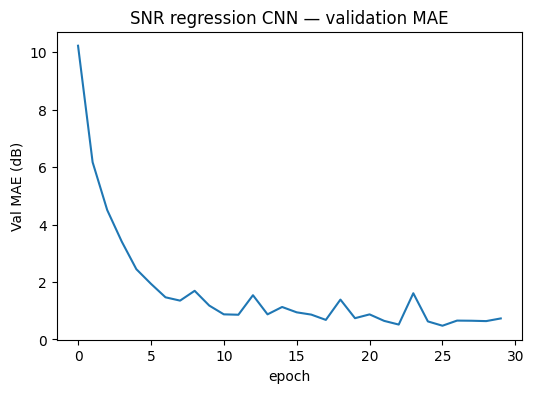

Final val MAE: 0.733 dB


In [28]:
# Cell 4 — full training
def train_snr_cnn(model, X_train, y_train, X_val, y_val, device,
                    epochs=30, batch_size=128, lr=1e-3, patience=5, seed=42):
    torch.manual_seed(seed)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    Xt, yt = torch.tensor(X_train, device=device), torch.tensor(y_train, device=device)
    Xv, yv = torch.tensor(X_val, device=device), torch.tensor(y_val, device=device)

    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_val, best_state, patience_ct = float("inf"), None, 0
    n = Xt.shape[0]

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        ep_losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            out = model(Xt[idx])
            loss = loss_fn(out, yt[idx])
            loss.backward(); opt.step()
            ep_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_out = model(Xv)
            val_loss = loss_fn(val_out, yv).item()
            val_mae = torch.mean(torch.abs(val_out - yv)).item()

        train_loss = float(np.mean(ep_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.3f}  val_loss={val_loss:.3f}  val_mae={val_mae:.3f} dB")

        if val_loss < best_val:
            best_val, best_state, patience_ct = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ct += 1
            if patience_ct >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_state)
    return model, history

model = SNRRegressionCNN(cfg.NSPS)
model, history = train_snr_cnn(model, X_train, y_train, X_val, y_val, device)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history["val_mae"])
plt.xlabel("epoch"); plt.ylabel("Val MAE (dB)")
plt.title("SNR regression CNN — validation MAE")
plt.savefig("figures/snr_cnn_training.png", dpi=150)
plt.show()

import os
os.makedirs("checkpoints", exist_ok=True)
torch.save(model.state_dict(), "checkpoints/snr_cnn.pt")
print(f"Final val MAE: {history['val_mae'][-1]:.3f} dB")

In [29]:
# in Colab, after Ctrl+S on the notebook
!git add checkpoints/snr_cnn.pt figures/snr_cnn_training.png notebooks/07_snr_estimation_and_grid.ipynb src/model.py
!git status

On branch main
Your branch and 'origin/main' have diverged,
and have 1 and 1 different commits each, respectively.
  (use "git pull" to merge the remote branch into yours)

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   checkpoints/snr_cnn.pt
	modified:   figures/snr_cnn_training.png



In [30]:
!git commit -m "Step 7: SNR regression CNN trained, val_mae=0.651dB"
!git push

[main ba2c834] Step 7: SNR regression CNN trained, val_mae=0.651dB
 2 files changed, 0 insertions(+), 0 deletions(-)
 rewrite checkpoints/snr_cnn.pt (92%)
 rewrite figures/snr_cnn_training.png (99%)
To https://github.com/Evenjlin/deep-space-interference-ml.git
 ! [rejected]        main -> main (non-fast-forward)
error: failed to push some refs to 'https://github.com/Evenjlin/deep-space-interference-ml.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [31]:
!git pull --no-edit

hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: invocation.
fatal: Need to specify how to reconcile divergent branches.


In [32]:
!git commit -m "Step 7: add SNRRegressionCNN and corrected_covariance to src/model.py"
!git push

On branch main
Your branch and 'origin/main' have diverged,
and have 2 and 1 different commits each, respectively.
  (use "git pull" to merge the remote branch into yours)

nothing to commit, working tree clean
To https://github.com/Evenjlin/deep-space-interference-ml.git
 ! [rejected]        main -> main (non-fast-forward)
error: failed to push some refs to 'https://github.com/Evenjlin/deep-space-interference-ml.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [33]:
!git push

To https://github.com/Evenjlin/deep-space-interference-ml.git
 ! [rejected]        main -> main (non-fast-forward)
error: failed to push some refs to 'https://github.com/Evenjlin/deep-space-interference-ml.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [34]:
!git log --oneline -5

ba2c834 (HEAD -> main) Step 7: SNR regression CNN trained, val_mae=0.651dB
b52844c Step 7: SNR regression CNN trained, val_mae=0.651dB
df9ee4b Step 7: SNR regression CNN + corrected covariance function (model + notebook, not yet run)
094dbac Consolidation: update README with project status summary
79da805 Step 6: compensated Mahalanobis run results (raw vs compensated AUC comparison)


In [35]:
!git config pull.rebase false
!git pull --no-edit

Merge made by the 'ort' strategy.
 notebooks/07_snr_estimation_and_grid.ipynb | 527 ++++++++++++++++++-----------
 1 file changed, 325 insertions(+), 202 deletions(-)


In [36]:
!git log --oneline --all --graph -10

*   21c7138 (HEAD -> main) Merge branch 'main' of https://github.com/Evenjlin/deep-space-interference-ml
|\  
| * b3c92b0 (origin/main, origin/HEAD) Step 7: SNR regression CNN trained, val_mae=0.651dB
* | ba2c834 Step 7: SNR regression CNN trained, val_mae=0.651dB
* | b52844c Step 7: SNR regression CNN trained, val_mae=0.651dB
|/  
* df9ee4b Step 7: SNR regression CNN + corrected covariance function (model + notebook, not yet run)
* 094dbac Consolidation: update README with project status summary
* 79da805 Step 6: compensated Mahalanobis run results (raw vs compensated AUC comparison)
* 730e633 Step 6: FFT frequency estimator + compensated Mahalanobis pipeline
* 2d85394 Step 6: document compensated Mahalanobis findings
* 9db440d Step 6: FFT frequency estimator + compensated Mahalanobis pipeline (model + notebook, not yet run)


In [37]:
!git push

Enumerating objects: 20, done.
Counting objects: 100% (18/18), done.
Delta compression using up to 2 threads
Compressing objects: 100% (14/14), done.
Writing objects: 100% (14/14), 128.86 KiB | 11.71 MiB/s, done.
Total 14 (delta 7), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (7/7), completed with 3 local objects.
To https://github.com/Evenjlin/deep-space-interference-ml.git
   b3c92b0..21c7138  main -> main


In [38]:
!git config --global pull.rebase false

In [39]:
!git log --oneline --all --graph -8

*   21c7138 (HEAD -> main, origin/main, origin/HEAD) Merge branch 'main' of https://github.com/Evenjlin/deep-space-interference-ml
|\  
| * b3c92b0 Step 7: SNR regression CNN trained, val_mae=0.651dB
* | ba2c834 Step 7: SNR regression CNN trained, val_mae=0.651dB
* | b52844c Step 7: SNR regression CNN trained, val_mae=0.651dB
|/  
* df9ee4b Step 7: SNR regression CNN + corrected covariance function (model + notebook, not yet run)
* 094dbac Consolidation: update README with project status summary
* 79da805 Step 6: compensated Mahalanobis run results (raw vs compensated AUC comparison)
* 730e633 Step 6: FFT frequency estimator + compensated Mahalanobis pipeline


In [43]:
# Cell 5 — reference covariance + both trained models, fully self-contained
import numpy as np
import torch
from src.channel import generate_soi, generate_noise, mix_signal, SignalConfig
from src.model import (estimate_covariance, mahalanobis_score, corrected_covariance,
                        SNRRegressionCNN, TimeShiftCNN, compensate_signal, complex_to_channels)
from sklearn.metrics import roc_auc_score

cfg_noshift = SignalConfig(fd_max=0.0)

# Load both trained models
timeshift_model = TimeShiftCNN(cfg.NSPS).to(device)
timeshift_model.load_state_dict(torch.load("checkpoints/timeshift_cnn.pt", map_location=device))
timeshift_model.eval()

snr_model = SNRRegressionCNN(cfg.NSPS).to(device)
snr_model.load_state_dict(torch.load("checkpoints/snr_cnn.pt", map_location=device))
snr_model.eval()
print("Both models loaded.")

def estimate_snr(x, model, device):
    channels = complex_to_channels(x).astype(np.float32)
    with torch.no_grad():
        inp = torch.tensor(channels, device=device).unsqueeze(0)
        return model(inp).item()

def make_clean_sample_local(cfg, n_symbols, snr_db, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    w = generate_noise(len(s), rng)
    rho_snr = 10 ** (snr_db / 10)
    return s + w / np.sqrt(rho_snr)

REF_SNR_DB = 15.0
M_TRAIN_REF = 4000
clean_ref = [make_clean_sample_local(cfg_noshift, N_SYMBOLS, REF_SNR_DB, rng) for _ in range(M_TRAIN_REF)]
C_ref = estimate_covariance(clean_ref)
C_ref_inv = np.linalg.inv(C_ref)

M_REF = 4000
soi_only, noise_only = [], []
for _ in range(M_REF):
    s, bits, fd, phi_m = generate_soi(cfg_noshift, N_SYMBOLS, rng)
    soi_only.append(s)
    noise_only.append(generate_noise(len(s), rng))

C_SOI = estimate_covariance(soi_only)
C_noise = estimate_covariance(noise_only)
print("C_ref, C_SOI, C_noise ready:", C_ref.shape, C_SOI.shape, C_noise.shape)

Both models loaded.
C_ref, C_SOI, C_noise ready: (1024, 1024) (1024, 1024) (1024, 1024)


In [45]:
# Cell 6 — the grid sweep (kept modest: 5x5 = 25 points, 100 samples/point for speed)
from src.model import TimeShiftCNN

timeshift_model = TimeShiftCNN(cfg.NSPS).to(device)
timeshift_model.load_state_dict(torch.load("checkpoints/timeshift_cnn.pt", map_location=device))
timeshift_model.eval()
print("Time-shift CNN loaded.")

SIR_GRID = np.linspace(-10, 30, 5)
SNR_GRID = np.linspace(-15, 30, 5)
N_TEST_PER_POINT = 100
ITYPE = "chirp"  # BASE-PAPER FACT: Fig.5-7 specifically use chirp interference

grid_results = []

for snr_db in SNR_GRID:
    for sir_db in SIR_GRID:
        samples, labels = [], []
        for _ in range(N_TEST_PER_POINT):
            d = mix_signal(cfg, N_SYMBOLS, rng, interference_type=ITYPE,
                            contamination=0.5, sir_db_range=(sir_db, sir_db),
                            snr_db_range=(snr_db, snr_db), apply_shift=True)
            samples.append(d["x"]); labels.append(d["label"])
        labels = np.array(labels)

        # Raw (uncompensated)
        raw_scores = [mahalanobis_score(x, C_ref_inv) for x in samples]
        raw_auc = roc_auc_score(labels, raw_scores)

        # Compensated (shift correction only, fixed reference covariance)
        comp_scores = []
        snr_hats = []
        for x in samples:
            x_corr, fd_hat, k_hat = compensate_signal(x, cfg, timeshift_model, device)
            comp_scores.append(mahalanobis_score(x_corr, C_ref_inv))
            snr_hats.append(estimate_snr(x_corr, snr_model, device))
        comp_auc = roc_auc_score(labels, comp_scores)

        # Compensated + SNR-corrected covariance (Eq.17)
        snr_corr_scores = []
        for x, corr_score_x, snr_hat in zip(samples, comp_scores, snr_hats):
            x_corr, _, _ = compensate_signal(x, cfg, timeshift_model, device)
            C_corrected = corrected_covariance(C_SOI, C_noise, snr_hat)
            C_corrected_inv = np.linalg.inv(C_corrected + 1e-6*np.eye(C_corrected.shape[0]))
            snr_corr_scores.append(mahalanobis_score(x_corr, C_corrected_inv))
        snr_corr_auc = roc_auc_score(labels, snr_corr_scores)

        grid_results.append({
            "snr_db": snr_db, "sir_db": sir_db,
            "raw_auc": raw_auc, "compensated_auc": comp_auc, "snr_corrected_auc": snr_corr_auc
        })
        print(f"SNR={snr_db:6.1f} SIR={sir_db:6.1f}  raw={raw_auc:.3f} comp={comp_auc:.3f} snr_corr={snr_corr_auc:.3f}")

import pandas as pd
grid_df = pd.DataFrame(grid_results)
grid_df.to_csv("results/step7_grid_sweep.csv", index=False)

Time-shift CNN loaded.
SNR= -15.0 SIR= -10.0  raw=0.887 comp=0.759 snr_corr=1.000
SNR= -15.0 SIR=   0.0  raw=0.626 comp=0.644 snr_corr=0.767
SNR= -15.0 SIR=  10.0  raw=0.450 comp=0.477 snr_corr=0.548
SNR= -15.0 SIR=  20.0  raw=0.362 comp=0.471 snr_corr=0.449
SNR= -15.0 SIR=  30.0  raw=0.423 comp=0.489 snr_corr=0.521
SNR=  -3.8 SIR= -10.0  raw=0.997 comp=0.985 snr_corr=1.000
SNR=  -3.8 SIR=   0.0  raw=0.920 comp=0.923 snr_corr=1.000
SNR=  -3.8 SIR=  10.0  raw=0.620 comp=0.610 snr_corr=0.620
SNR=  -3.8 SIR=  20.0  raw=0.560 comp=0.571 snr_corr=0.534
SNR=  -3.8 SIR=  30.0  raw=0.594 comp=0.450 snr_corr=0.519
SNR=   7.5 SIR= -10.0  raw=1.000 comp=1.000 snr_corr=1.000
SNR=   7.5 SIR=   0.0  raw=0.960 comp=1.000 snr_corr=1.000
SNR=   7.5 SIR=  10.0  raw=0.608 comp=0.897 snr_corr=0.717
SNR=   7.5 SIR=  20.0  raw=0.552 comp=0.663 snr_corr=0.486
SNR=   7.5 SIR=  30.0  raw=0.514 comp=0.447 snr_corr=0.530
SNR=  18.8 SIR= -10.0  raw=1.000 comp=1.000 snr_corr=1.000
SNR=  18.8 SIR=   0.0  raw=0.969 